# Notebook 1 — Bail Outcome Prediction
## Can we predict whether a bail application will be Allowed or Rejected?

**Research question:** Do structural features — which court, what bail type, which year, how many hearings —
predict bail outcomes? If outcomes are highly predictable from features unrelated to case merits,
it raises systemic-bias concerns.

**Method:** Logistic Regression (baseline) -> Random Forest -> XGBoost with SHAP interpretability.
Target-encoding for `NAME_OF_HIGH_COURT` is fit **only on training data** (K-fold within train + hold-out map for test); numeric imputation uses **training medians** only. `NATURE_OF_DISPOSAL_BINARY` is excluded (it is recorded with disposition and leaks the outcome). Metrics include ROC-AUC, PR-AUC (better for imbalance), balanced accuracy, and macro-F1 alongside weighted F1.

### [!]️ Selection-bias caveat
`NATURE_OF_DISPOSAL_OUTCOME` is **69.3% missing**. The model dataset (~285K rows) covers only
courts/periods that record outcomes — predominantly Allahabad, Rajasthan, Jharkhand and Gawhati.
Results do **not** generalise to the full dataset. We document the coverage explicitly below.


In [11]:
# ── A. Setup ─────────────────────────────────────────────────────────────────
# pip install xgboost shap category_encoders  (if not already installed)
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("Compiled Bail case data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Cannot locate 'Compiled Bail case data.csv'. "
        "Place it next to this notebook."
    )
print(f"Data path: {DATA_PATH}")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, balanced_accuracy_score,
                              classification_report, RocCurveDisplay, PrecisionRecallDisplay, f1_score)
import xgboost as xgb
import shap


Data path: Compiled Bail case data.csv


## B. Load & Filter Data

In [12]:
COLS = [
    "NAME_OF_HIGH_COURT", "Mapped_Bail", "YEAR", "HEARING_COUNT",
    "DATE_FILED", "REGISTRATION_DATE", "NATURE_OF_DISPOSAL_OUTCOME",
    "NATURE_OF_DISPOSAL_BINARY", "DISPOSAL_DAYS...1", "CURRENT_STATUS",
]
raw = pd.read_csv(DATA_PATH, usecols=COLS, low_memory=False)

for col in ["DATE_FILED", "REGISTRATION_DATE"]:
    ymd = pd.to_datetime(raw[col], format="%Y-%m-%d", errors="coerce")
    dmy = pd.to_datetime(raw[col], format="%d-%m-%Y", errors="coerce")
    raw[col] = ymd.fillna(dmy)

raw["DISPOSAL_DAYS"] = pd.to_numeric(raw["DISPOSAL_DAYS...1"], errors="coerce")
raw["HEARING_COUNT"]  = pd.to_numeric(raw["HEARING_COUNT"],     errors="coerce")
raw["filing_month"]   = raw["DATE_FILED"].dt.month
raw["reg_lag"]        = (raw["REGISTRATION_DATE"] - raw["DATE_FILED"]).dt.days.clip(lower=0)
raw["log_hearing"]    = np.log1p(raw["HEARING_COUNT"])

# Filter: disposed cases with a recorded outcome
df = raw[
    (raw["CURRENT_STATUS"] == "Disposed") &
    raw["NATURE_OF_DISPOSAL_OUTCOME"].notna()
].copy()

print(f"Total rows: {len(raw):,}")
print(f"Model dataset (outcome known): {len(df):,} ({len(df)/len(raw)*100:.1f}%)")


Total rows: 927,896
Model dataset (outcome known): 284,584 (30.7%)


## C. Selection-Bias Documentation
Which courts contribute to the outcome-known subset?

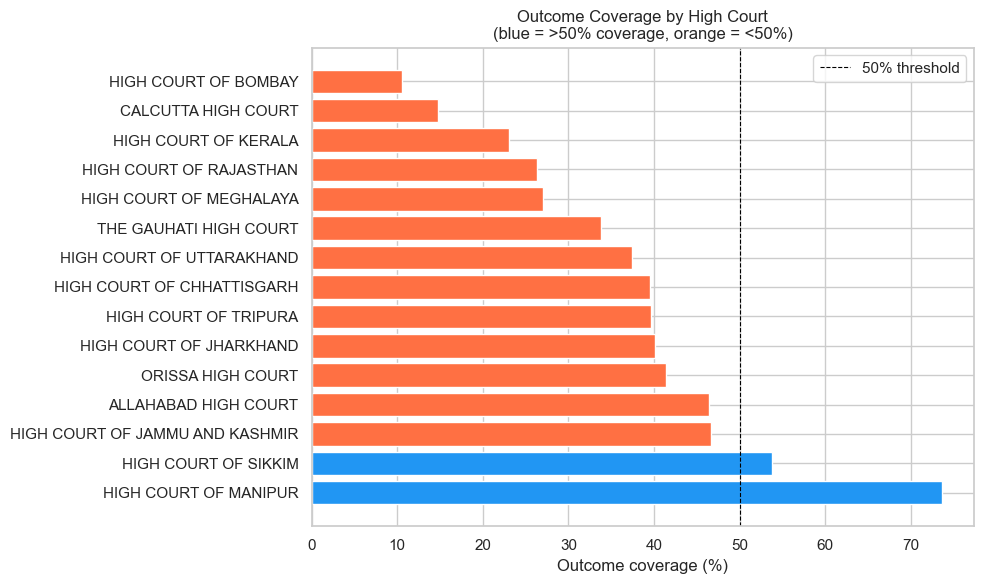


Coverage table:


,with_outcome,total,coverage_pct
NAME_OF_HIGH_COURT,,,
HIGH COURT OF MANIPUR,331,449,73.7
HIGH COURT OF SIKKIM,42,78,53.8
HIGH COURT OF JAMMU AND KASHMIR,945,2022,46.7
ALLAHABAD HIGH COURT,11936,25733,46.4
ORISSA HIGH COURT,71918,173769,41.4
HIGH COURT OF JHARKHAND,62216,155243,40.1
HIGH COURT OF TRIPURA,1219,3077,39.6
HIGH COURT OF CHHATTISGARH,6915,17493,39.5
HIGH COURT OF UTTARAKHAND,10174,27167,37.4



[!]️  Model conclusions are most reliable for high-coverage courts.


In [13]:
coverage = (
    raw.assign(has_outcome=raw["NATURE_OF_DISPOSAL_OUTCOME"].notna())
       .groupby("NAME_OF_HIGH_COURT")["has_outcome"]
       .agg(["sum", "count"])
       .rename(columns={"sum": "with_outcome", "count": "total"})
)
coverage["coverage_pct"] = (coverage["with_outcome"] / coverage["total"] * 100).round(1)
coverage = coverage.sort_values("coverage_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2196F3" if v > 50 else "#FF7043" for v in coverage["coverage_pct"]]
ax.barh(coverage.index, coverage["coverage_pct"], color=colors)
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, label="50% threshold")
ax.set_xlabel("Outcome coverage (%)")
ax.set_title("Outcome Coverage by High Court\n(blue = >50% coverage, orange = <50%)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nCoverage table:")
display(coverage)
print("\n[!]️  Model conclusions are most reliable for high-coverage courts.")


## D. Target Variable & Class Balance

Top raw outcome values:


outcome_raw
ALLOWED                                              99295
DISPOSED OFF                                         48582
BAIL                                                 33024
DISPOSED OF                                          25057
DISMISSED                                            20435
REJECTED                                             18016
WITHDRAWN                                             8048
ALLOWED/PARTLY ALLOWED ON MERITS                      5628
DISPOSED                                              4607
DISMISSED AS WITHDRAWN                                3903
DISPOSED OFF/DECIDED ON MERITS                        2446
DISMISSED ON MERITS                                   2373
GRANTED                                               1724
DISMISSED AS NOT PRESSED                              1401
DISMISS OTHER THAN MERIT(DD/NON PROSEC./ABATED)       1395
CLOSED                                                1248
ALLOWED TO BE WITHDRAWN                     


After binary mapping: 148,040 rows
ALLOWED: 101,108 (68.3%)
REJECTED: 46,932 (31.7%)


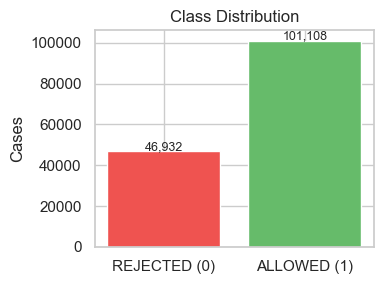

In [14]:
# Normalise outcome strings
df["outcome_raw"] = df["NATURE_OF_DISPOSAL_OUTCOME"].str.strip().str.upper()

ALLOWED_TERMS  = {"ALLOWED", "BAIL ALLOWED", "GRANTED", "BAIL GRANTED",
                  "APPLICATION ALLOWED", "DISPOSED OF AS ALLOWED"}
REJECTED_TERMS = {"REJECTED", "DISMISSED", "BAIL REJECTED", "BAIL DISMISSED",
                  "APPLICATION REJECTED", "APPLICATION DISMISSED", "NOT PRESSED",
                  "WITHDRAWN", "DISPOSED OF AS DISMISSED"}

def map_outcome(val):
    if val in ALLOWED_TERMS:
        return 1
    elif val in REJECTED_TERMS:
        return 0
    return np.nan

df["TARGET"] = df["outcome_raw"].map(map_outcome)

# Show raw outcome distribution before binary mapping
print("Top raw outcome values:")
display(df["outcome_raw"].value_counts().head(20))

df_clean = df.dropna(subset=["TARGET"]).copy()
df_clean["TARGET"] = df_clean["TARGET"].astype(int)

allowed_rate = df_clean["TARGET"].mean()
print(f"\nAfter binary mapping: {len(df_clean):,} rows")
print(f"ALLOWED: {df_clean['TARGET'].sum():,} ({allowed_rate*100:.1f}%)")
print(f"REJECTED: {(df_clean['TARGET']==0).sum():,} ({(1-allowed_rate)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["REJECTED (0)", "ALLOWED (1)"],
       [df_clean["TARGET"].value_counts()[0], df_clean["TARGET"].value_counts()[1]],
       color=["#EF5350", "#66BB6A"])
ax.set_ylabel("Cases")
ax.set_title("Class Distribution")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{bar.get_height():,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


## E. Feature Engineering, hold-out split, and target encoding
We **split first**, then (1) impute numeric gaps with **training-set medians** only, (2) target-encode courts with **K-fold smoothing on the training set** and a **train-derived** map for the test set (test labels never enter encodings). `NATURE_OF_DISPOSAL_BINARY` is omitted because it is disposition-time metadata and would leak information about the outcome.

In [15]:
# Exclude NATURE_OF_DISPOSAL_BINARY: recorded at disposition alongside outcome → label leakage.
FEATURES = ["NAME_OF_HIGH_COURT", "Mapped_Bail", "YEAR", "log_hearing",
            "filing_month", "reg_lag"]

df_model = df_clean[FEATURES + ["TARGET"]].copy()

# Encode Mapped_Bail (OHE — only 3 levels)
df_model = pd.get_dummies(df_model, columns=["Mapped_Bail"], drop_first=False)

# Numeric NAs imputed after train/test split using training medians only (see next cell).

X_raw = df_model.drop(columns=["TARGET"])
y     = df_model["TARGET"].values

print(f"Feature matrix shape: {X_raw.shape}")
print(f"Features: {X_raw.columns.tolist()}")


Feature matrix shape: (148040, 8)
Features: ['NAME_OF_HIGH_COURT', 'YEAR', 'log_hearing', 'filing_month', 'reg_lag', 'Mapped_Bail_ANTICIPATORY BAIL', 'Mapped_Bail_CANCELLATION', 'Mapped_Bail_REGULAR BAIL']


In [16]:
# ── Hold-out split FIRST, then train-only imputation & target encoding ───────
ALPHA = 10  # smoothing strength for target encoding

def target_encode_kfold_train(X_train, y_train, col, n_splits=5, alpha=10):
    """Within-training CV only: each train row encoded without using its own label in that fold."""
    global_mean = y_train.mean()
    enc_col = np.zeros(len(X_train))
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for tr_idx, val_idx in kf.split(X_train, y_train):
        stats = (
            pd.DataFrame({"cat": X_train[col].iloc[tr_idx], "y": y_train[tr_idx]})
              .groupby("cat")["y"]
              .agg(["mean", "count"])
        )
        stats["smoothed"] = (
            (stats["mean"] * stats["count"] + global_mean * alpha) /
            (stats["count"] + alpha)
        )
        enc_map = stats["smoothed"].to_dict()
        enc_col[val_idx] = X_train[col].iloc[val_idx].map(enc_map).fillna(global_mean)
    return enc_col, global_mean


def target_encode_test_from_train(X_train, y_train, X_test, col, alpha=10):
    """Test rows: smoothed court rates from training labels only (no test leakage)."""
    global_mean = y_train.mean()
    stats = (
        pd.DataFrame({"cat": X_train[col], "y": y_train})
          .groupby("cat")["y"]
          .agg(["mean", "count"])
    )
    stats["smoothed"] = (
        (stats["mean"] * stats["count"] + global_mean * alpha) /
        (stats["count"] + alpha)
    )
    enc_map = stats["smoothed"].to_dict()
    return X_test[col].map(enc_map).fillna(global_mean).values, global_mean


tr_idx, te_idx = train_test_split(
    np.arange(len(y)), test_size=0.2, stratify=y, random_state=42
)
X_tr_raw = X_raw.iloc[tr_idx].reset_index(drop=True)
X_te_raw = X_raw.iloc[te_idx].reset_index(drop=True)
y_train = y[tr_idx]
y_test = y[te_idx]

NUM_COLS = ["YEAR", "log_hearing", "filing_month", "reg_lag"]
for col in NUM_COLS:
    med = X_tr_raw[col].median()
    X_tr_raw[col] = X_tr_raw[col].fillna(med)
    X_te_raw[col] = X_te_raw[col].fillna(med)

enc_train, global_mean_court = target_encode_kfold_train(
    X_tr_raw, y_train, "NAME_OF_HIGH_COURT", alpha=ALPHA
)
enc_test, _ = target_encode_test_from_train(
    X_tr_raw, y_train, X_te_raw, "NAME_OF_HIGH_COURT", alpha=ALPHA
)

X_train = X_tr_raw.drop(columns=["NAME_OF_HIGH_COURT"]).copy()
X_test = X_te_raw.drop(columns=["NAME_OF_HIGH_COURT"]).copy()
X_train["court_te"] = enc_train
X_test["court_te"] = enc_test

# Full-length vector for SHAP / diagnostics (same order as X_raw, y)
enc_vals = np.empty(len(y), dtype=float)
enc_vals[tr_idx] = enc_train
enc_vals[te_idx] = enc_test

print("Target encoding applied (train-only statistics). Sample court → encoded value:")
mapping_check = (
    pd.DataFrame({"court": X_raw["NAME_OF_HIGH_COURT"].values, "te_value": enc_vals})
      .drop_duplicates()
      .sort_values("te_value", ascending=False)
)
display(mapping_check.head(10))

print(f"\nTrain: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Train ALLOWED rate: {y_train.mean():.3f}  |  Test ALLOWED rate: {y_test.mean():.3f}")


Target encoding applied (train-only statistics). Sample court → encoded value:


,court,te_value
140309,HIGH COURT OF UTTARAKHAND,0.872271
140310,HIGH COURT OF UTTARAKHAND,0.870523
140307,HIGH COURT OF UTTARAKHAND,0.869308
140306,HIGH COURT OF UTTARAKHAND,0.868582
140305,HIGH COURT OF UTTARAKHAND,0.867634
140324,HIGH COURT OF UTTARAKHAND,0.867265
68325,ORISSA HIGH COURT,0.773682
68304,ORISSA HIGH COURT,0.771285
68303,ORISSA HIGH COURT,0.770890
68305,ORISSA HIGH COURT,0.770885



Train: 118,432  |  Test: 29,608
Train ALLOWED rate: 0.683  |  Test ALLOWED rate: 0.683


## F. Train / Test summary
Row counts and class balance are printed at the end of section **E** (stratified 80/20 split, `random_state=42`).

In [17]:
# X_train, X_test, y_train, y_test and TR_IDX are defined in section E.
TR_IDX, TE_IDX = tr_idx, te_idx


## G. Model 1 — Logistic Regression (Baseline)

In [18]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr   = lr_pipe.predict(X_test)
y_proba_lr  = lr_pipe.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, y_proba_lr)
lr_ap  = average_precision_score(y_test, y_proba_lr)
lr_ba  = balanced_accuracy_score(y_test, y_pred_lr)
lr_f1w = f1_score(y_test, y_pred_lr, average="weighted")
lr_f1m = f1_score(y_test, y_pred_lr, average="macro")
print(f"Logistic Regression — ROC-AUC: {lr_auc:.4f}  |  PR-AUC: {lr_ap:.4f}  |  Balanced acc: {lr_ba:.4f}")
print(f"  Weighted F1: {lr_f1w:.4f}  |  Macro F1: {lr_f1m:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["REJECTED", "ALLOWED"]))


Logistic Regression — ROC-AUC: 0.6450  |  PR-AUC: 0.7849  |  Balanced acc: 0.6000
  Weighted F1: 0.6502  |  Macro F1: 0.5986

Classification Report:
              precision    recall  f1-score   support

    REJECTED       0.45      0.47      0.46      9386
     ALLOWED       0.75      0.73      0.74     20222

    accuracy                           0.65     29608
   macro avg       0.60      0.60      0.60     29608
weighted avg       0.65      0.65      0.65     29608



## H. Model 2 — Random Forest

In [19]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=20,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, y_proba_rf)
rf_ap  = average_precision_score(y_test, y_proba_rf)
rf_ba  = balanced_accuracy_score(y_test, y_pred_rf)
rf_f1w = f1_score(y_test, y_pred_rf, average="weighted")
rf_f1m = f1_score(y_test, y_pred_rf, average="macro")
print(f"Random Forest — ROC-AUC: {rf_auc:.4f}  |  PR-AUC: {rf_ap:.4f}  |  Balanced acc: {rf_ba:.4f}")
print(f"  Weighted F1: {rf_f1w:.4f}  |  Macro F1: {rf_f1m:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["REJECTED", "ALLOWED"]))


Random Forest — ROC-AUC: 0.6959  |  PR-AUC: 0.8193  |  Balanced acc: 0.6330
  Weighted F1: 0.6725  |  Macro F1: 0.6281

Classification Report:
              precision    recall  f1-score   support

    REJECTED       0.48      0.54      0.51      9386
     ALLOWED       0.77      0.73      0.75     20222

    accuracy                           0.67     29608
   macro avg       0.63      0.63      0.63     29608
weighted avg       0.68      0.67      0.67     29608



## I. Model 3 — XGBoost (Primary Model)

In [20]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

# Internal validation for early stopping — never use the held-out test set for tuning.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=43
)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric="auc",
    early_stopping_rounds=30,
    random_state=42,
    use_label_encoder=False,
)
xgb_model.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Refit on full training data using best iteration (test set still untouched).
best_it = getattr(xgb_model, "best_iteration", None)
if best_it is not None:
    xgb_model.set_params(n_estimators=max(1, int(best_it) + 1),
                     early_stopping_rounds=None)
xgb_model.fit(X_train, y_train, verbose=False)

y_pred_xgb   = xgb_model.predict(X_test)
y_proba_xgb  = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, y_proba_xgb)
xgb_ap  = average_precision_score(y_test, y_proba_xgb)
xgb_ba  = balanced_accuracy_score(y_test, y_pred_xgb)
xgb_f1w = f1_score(y_test, y_pred_xgb, average="weighted")
xgb_f1m = f1_score(y_test, y_pred_xgb, average="macro")
print(f"XGBoost — ROC-AUC: {xgb_auc:.4f}  |  PR-AUC: {xgb_ap:.4f}  |  Balanced acc: {xgb_ba:.4f}")
print(f"  Weighted F1: {xgb_f1w:.4f}  |  Macro F1: {xgb_f1m:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=["REJECTED", "ALLOWED"]))


XGBoost — ROC-AUC: 0.6994  |  PR-AUC: 0.8217  |  Balanced acc: 0.6363
  Weighted F1: 0.6695  |  Macro F1: 0.6280

Classification Report:
              precision    recall  f1-score   support

    REJECTED       0.47      0.56      0.51      9386
     ALLOWED       0.78      0.71      0.74     20222

    accuracy                           0.66     29608
   macro avg       0.63      0.64      0.63     29608
weighted avg       0.68      0.66      0.67     29608



## J. Model Comparison

,ROC-AUC,PR-AUC,Balanced-acc,Weighted-F1,Macro-F1
Model,,,,,
Logistic Regression,0.6450,0.7849,0.6000,0.6502,0.5986
Random Forest,0.6959,0.8193,0.6330,0.6725,0.6281
XGBoost,0.6994,0.8217,0.6363,0.6695,0.6280


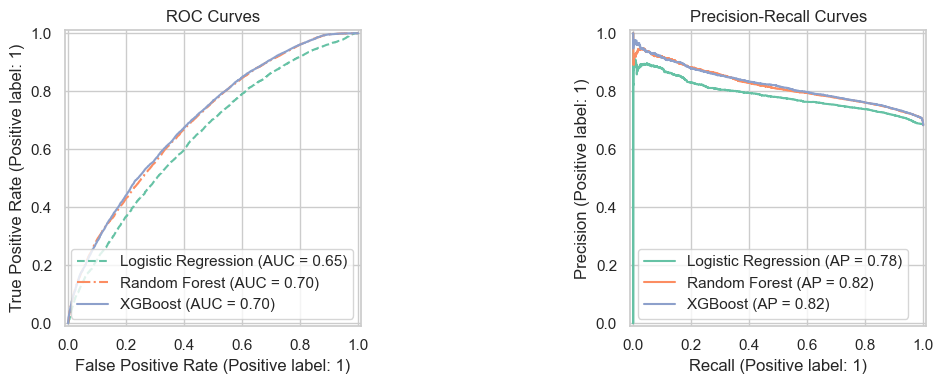

In [21]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC":      [lr_auc, rf_auc, xgb_auc],
    "PR-AUC":       [lr_ap,  rf_ap,  xgb_ap],
    "Balanced-acc": [lr_ba,  rf_ba,  xgb_ba],
    "Weighted-F1": [lr_f1w, rf_f1w, xgb_f1w],
    "Macro-F1":     [lr_f1m, rf_f1m, xgb_f1m],
}).set_index("Model").round(4)
display(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for proba, label, ls in [
    (y_proba_lr,  "Logistic Regression", "--"),
    (y_proba_rf,  "Random Forest",       "-."),
    (y_proba_xgb, "XGBoost",             "-"),
]:
    RocCurveDisplay.from_predictions(y_test, proba, name=label, ax=axes[0], linestyle=ls)
axes[0].set_title("ROC Curves")

for proba, label in [
    (y_proba_lr,  "Logistic Regression"),
    (y_proba_rf,  "Random Forest"),
    (y_proba_xgb, "XGBoost"),
]:
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=label, ax=axes[1])
axes[1].set_title("Precision-Recall Curves")

plt.tight_layout()
plt.show()


## K. SHAP Analysis — Global Feature Importance

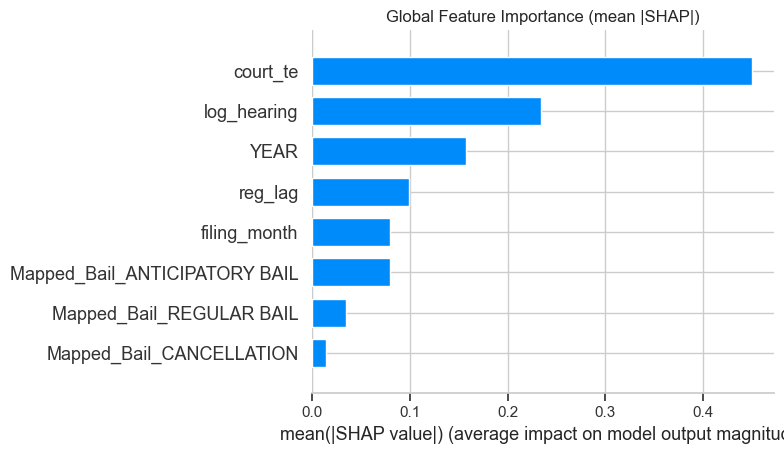

In [22]:
explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_test)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()


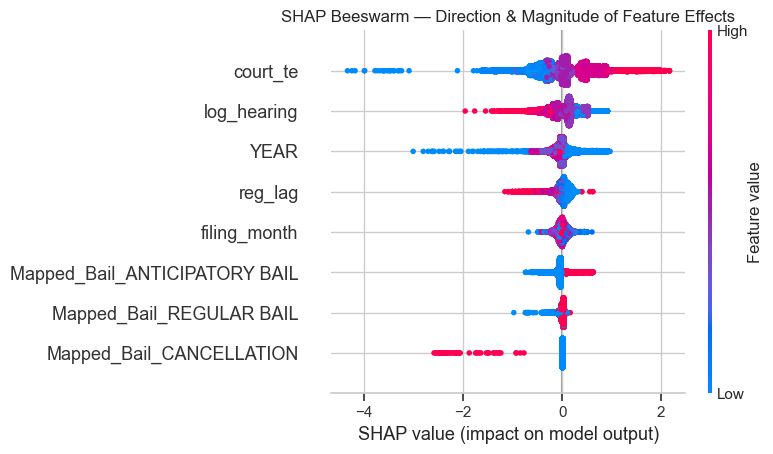

Interpretation guide: /n Red points = high feature value; Blue = low /n Points right = ALLOWED; Points left = REJECTED


In [23]:
# Beeswarm (shows direction of effect)
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm — Direction & Magnitude of Feature Effects")
plt.tight_layout()
plt.show()
print("Interpretation guide: /n Red points = high feature value; Blue = low /n Points right = ALLOWED; Points left = REJECTED")


## L. Court-Level SHAP Deviation
Does the same case profile receive systematically different predictions across courts?

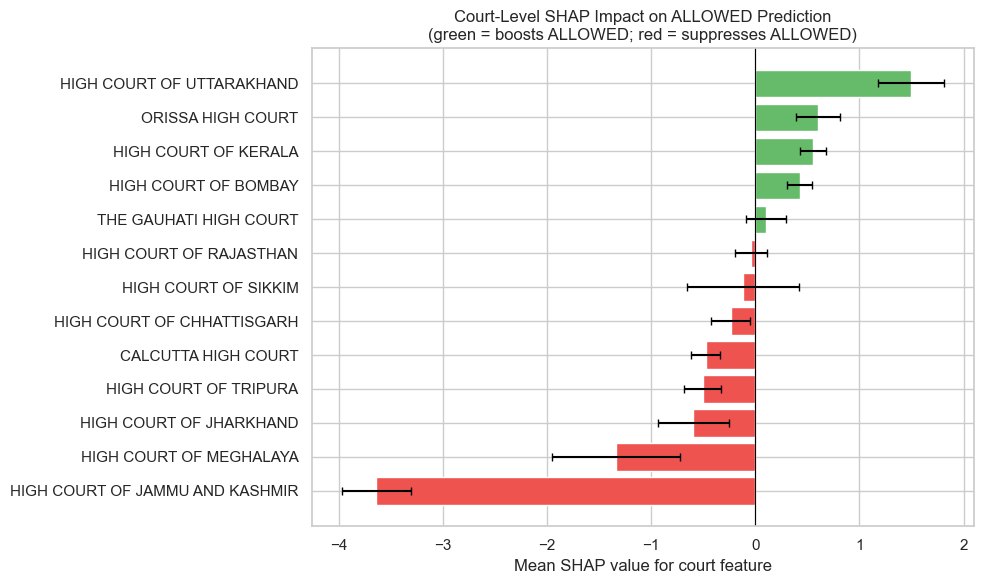


These are marginal court effects AFTER controlling for bail type, year, and hearing count (no contested flag — it was removed as outcome-adjacent).


In [24]:
# Extract court_te SHAP values
court_te_idx = list(X_test.columns).index("court_te")
court_shap   = shap_values[:, court_te_idx]

court_shap_df = pd.DataFrame({
    "court_te":   X_test["court_te"].values,
    "shap_court": court_shap
})

# Map back to court name via the encoding
mapping_clean = (
    pd.DataFrame({"court": X_raw["NAME_OF_HIGH_COURT"], "te": enc_vals})
      .drop_duplicates()
      .sort_values("te")
)
te_to_court = dict(zip(mapping_clean["te"].round(4), mapping_clean["court"]))

# Bin by nearest encoded value
court_shap_df["court"] = court_shap_df["court_te"].round(4).map(te_to_court)
court_shap_agg = (
    court_shap_df.groupby("court")["shap_court"]
                 .agg(["mean", "std", "count"])
                 .sort_values("mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#66BB6A" if v > 0 else "#EF5350" for v in court_shap_agg["mean"]]
ax.barh(court_shap_agg.index, court_shap_agg["mean"], color=colors, xerr=court_shap_agg["std"], capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean SHAP value for court feature")
ax.set_title("Court-Level SHAP Impact on ALLOWED Prediction\n(green = boosts ALLOWED; red = suppresses ALLOWED)")
plt.tight_layout()
plt.show()
print("\nThese are marginal court effects AFTER controlling for bail type, year, and hearing count (no contested flag — it was removed as outcome-adjacent).")


## M. OHE Comparison (Robustness Check)

In [25]:
# Re-encode with one-hot instead of target encoding (same train/test row indices as §E)
X_ohe = pd.get_dummies(X_raw, columns=["NAME_OF_HIGH_COURT"], drop_first=False)
for col in X_ohe.columns:
    X_ohe[col] = pd.to_numeric(X_ohe[col], errors="coerce").fillna(0)

X_train_ohe = X_ohe.iloc[TR_IDX].reset_index(drop=True)
X_test_ohe = X_ohe.iloc[TE_IDX].reset_index(drop=True)
y_train_ohe = y[TR_IDX]
y_test_ohe = y[TE_IDX]

X_fit_ohe, X_val_ohe, y_fit_ohe, y_val_ohe = train_test_split(
    X_train_ohe, y_train_ohe, test_size=0.15, stratify=y_train_ohe, random_state=44
)

xgb_ohe = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric="auc", random_state=42, use_label_encoder=False,
    early_stopping_rounds=20,
)
xgb_ohe.fit(X_fit_ohe, y_fit_ohe, eval_set=[(X_val_ohe, y_val_ohe)], verbose=False)
bi_ohe = getattr(xgb_ohe, "best_iteration", None)
if bi_ohe is not None:
    xgb_ohe.set_params(n_estimators=max(1, int(bi_ohe) + 1),
                   early_stopping_rounds=None)
xgb_ohe.fit(X_train_ohe, y_train_ohe, verbose=False)

ohe_auc = roc_auc_score(y_test_ohe, xgb_ohe.predict_proba(X_test_ohe)[:, 1])
print(f"XGBoost (OHE encoding) AUC:    {ohe_auc:.4f}")
print(f"XGBoost (Target encoding) AUC: {xgb_auc:.4f}")
print(f"Difference: {abs(ohe_auc - xgb_auc):.4f}")
print("\nIf AUC values are close, results are robust to encoding choice.")


XGBoost (OHE encoding) AUC:    0.6967
XGBoost (Target encoding) AUC: 0.6994
Difference: 0.0026

If AUC values are close, results are robust to encoding choice.


## O. Handling Class Imbalance — Resampling Techniques

The original dataset has a **68.3% / 31.7% imbalance** (ALLOWED vs REJECTED).  
The models in sections G–I used `class_weight="balanced"` / `scale_pos_weight` — a *cost-sensitive* approach that reweights the loss, but does **not** change the training data distribution.

Here we test three explicit resampling strategies and compare them against the baseline XGBoost:

| Strategy | Type | Idea |
|----------|------|------|
| **SMOTE** | Oversampling | Synthesises new REJECTED cases by interpolating between existing nearest neighbours |
| **SVM-SMOTE** | Oversampling | Like SMOTE, but generates synthetic samples only near the SVM decision boundary (support vectors) — more targeted |
| **Condensed Nearest Neighbour (CNN)** | Undersampling | Removes ALLOWED cases that are easily classified; retains only boundary-hugging majority samples |

**SVM-SMOTE logic:** trains an SVM on the minority class, identifies support vectors (instances closest to the decision boundary), and synthesises new samples only around those — avoiding noise in the interior of the minority cluster.

> All resampling is applied **only on the training set**. The test set (29,608 rows) is never touched.  
> The downstream classifier for all three is XGBoost, so differences in AUC are attributable to resampling alone.  
> **Early stopping:** XGBoost `eval_set` is a stratified hold-out from the (resampled) training data; the held-out test set is used only for final metrics after refitting with `best_iteration`.


In [26]:
# ── O1. Imports ───────────────────────────────────────────────────────────────
# pip install imbalanced-learn  (if not already installed)
from imblearn.over_sampling import SMOTE, SVMSMOTE
from imblearn.under_sampling import CondensedNearestNeighbour

print("imbalanced-learn imported successfully.")
print(f"\nTraining set shape : {X_train.shape}")
print(f"ALLOWED  : {y_train.sum():,}  ({y_train.mean()*100:.1f}%)")
print(f"REJECTED : {(y_train==0).sum():,}  ({(1-y_train.mean())*100:.1f}%)")

imbalanced-learn imported successfully.

Training set shape : (118432, 8)
ALLOWED  : 80,886  (68.3%)
REJECTED : 37,546  (31.7%)


In [27]:
#  O2. SMOTE
# SMOTE creates synthetic REJECTED samples by interpolating between each minority
# instance and its k nearest minority neighbours (default k=5).
# FIX: Split into train/val folds FIRST, then apply SMOTE only to the train fold.
# This prevents synthetic val-fold samples leaking into the training oversample.

# 1. Split before any oversampling
X_sm_fit_raw, X_sm_val, y_sm_fit_raw, y_sm_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=45
)

# 2. Apply SMOTE only to the training fold
smote = SMOTE(random_state=42, k_neighbors=5)
X_sm_fit, y_sm_fit = smote.fit_resample(X_sm_fit_raw, y_sm_fit_raw)

print(f"After SMOTE (train fold) shape: {X_sm_fit.shape}")
print(f"ALLOWED  : {y_sm_fit.sum():,}  ({y_sm_fit.mean()*100:.1f}%)")
print(f"REJECTED : {(y_sm_fit==0).sum():,}  ({(1-y_sm_fit.mean())*100:.1f}%)")

xgb_smote = xgb.XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="auc", early_stopping_rounds=30,
    random_state=42, use_label_encoder=False,
)
# 3. Early-stop on original (unaugmented) val fold — no leakage
xgb_smote.fit(X_sm_fit, y_sm_fit, eval_set=[(X_sm_val, y_sm_val)], verbose=False)
bi = getattr(xgb_smote, "best_iteration", None)

# 4. Refit on full (fresh) SMOTE-augmented training set with early stopping disabled
X_sm, y_sm = smote.fit_resample(X_train, y_train)
if bi is not None:
    xgb_smote.set_params(n_estimators=max(1, int(bi) + 1),
                         early_stopping_rounds=None)
xgb_smote.fit(X_sm, y_sm, verbose=False)

y_pred_smote  = xgb_smote.predict(X_test)
y_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]

smote_auc = roc_auc_score(y_test, y_proba_smote)
smote_ap  = average_precision_score(y_test, y_proba_smote)
smote_f1  = f1_score(y_test, y_pred_smote, average="weighted")
print(f"\nXGBoost + SMOTE  ROC-AUC: {smote_auc:.4f}  |  PR-AUC: {smote_ap:.4f}  |  Weighted F1: {smote_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote, target_names=["REJECTED", "ALLOWED"]))

After SMOTE (train fold) shape: (137506, 8)
ALLOWED  : 68,753  (50.0%)
REJECTED : 68,753  (50.0%)

XGBoost + SMOTE  ROC-AUC: 0.6529  |  PR-AUC: 0.7983  |  Weighted F1: 0.5226

Classification Report:
              precision    recall  f1-score   support

    REJECTED       0.37      0.78      0.51      9386
     ALLOWED       0.79      0.40      0.53     20222

    accuracy                           0.52     29608
   macro avg       0.58      0.59      0.52     29608
weighted avg       0.66      0.52      0.52     29608



In [28]:
#  O3. SVM-SMOTE
# SVM-SMOTE generates synthetic REJECTED samples near the SVM decision boundary.
# FIX: Split into train/val folds FIRST, then apply SVM-SMOTE only to the train fold.

# 1. Split before any oversampling
X_sv_fit_raw, X_sv_val, y_sv_fit_raw, y_sv_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=46
)

# 2. Apply SVM-SMOTE only to the training fold
svm_smote = SVMSMOTE(random_state=42, k_neighbors=5)
X_sv_fit, y_sv_fit = svm_smote.fit_resample(X_sv_fit_raw, y_sv_fit_raw)

print(f"After SVM-SMOTE (train fold) shape: {X_sv_fit.shape}")
print(f"ALLOWED  : {y_sv_fit.sum():,}  ({y_sv_fit.mean()*100:.1f}%)")
print(f"REJECTED : {(y_sv_fit==0).sum():,}  ({(1-y_sv_fit.mean())*100:.1f}%)")

xgb_svmsmote = xgb.XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="auc", early_stopping_rounds=30,
    random_state=42, use_label_encoder=False,
)
# 3. Early-stop on original (unaugmented) val fold — no leakage
xgb_svmsmote.fit(X_sv_fit, y_sv_fit, eval_set=[(X_sv_val, y_sv_val)], verbose=False)
bi2 = getattr(xgb_svmsmote, "best_iteration", None)

# 4. Refit on full (fresh) SVM-SMOTE-augmented training set with early stopping disabled
X_svms, y_svms = svm_smote.fit_resample(X_train, y_train)
if bi2 is not None:
    xgb_svmsmote.set_params(n_estimators=max(1, int(bi2) + 1),
                            early_stopping_rounds=None)
xgb_svmsmote.fit(X_svms, y_svms, verbose=False)

y_pred_svms  = xgb_svmsmote.predict(X_test)
y_proba_svms = xgb_svmsmote.predict_proba(X_test)[:, 1]

svms_auc = roc_auc_score(y_test, y_proba_svms)
svms_ap  = average_precision_score(y_test, y_proba_svms)
svms_f1  = f1_score(y_test, y_pred_svms, average="weighted")
print(f"\nXGBoost + SVM-SMOTE  ROC-AUC: {svms_auc:.4f}  |  PR-AUC: {svms_ap:.4f}  |  Weighted F1: {svms_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svms, target_names=["REJECTED", "ALLOWED"]))

After SVM-SMOTE (train fold) shape: (137506, 8)
ALLOWED  : 68,753  (50.0%)
REJECTED : 68,753  (50.0%)

XGBoost + SVM-SMOTE  ROC-AUC: 0.6719  |  PR-AUC: 0.8097  |  Weighted F1: 0.6556

Classification Report:
              precision    recall  f1-score   support

    REJECTED       0.45      0.54      0.50      9386
     ALLOWED       0.77      0.70      0.73     20222

    accuracy                           0.65     29608
   macro avg       0.61      0.62      0.61     29608
weighted avg       0.67      0.65      0.66     29608



,ROC-AUC,PR-AUC,Weighted-F1,REJECTED-Precision,REJECTED-Recall
Strategy,,,,,
XGBoost (baseline — scale_pos_weight),0.6994,0.8217,0.6695,0.4730,0.5644
XGBoost + SMOTE,0.6529,0.7983,0.5226,0.3746,0.7758
XGBoost + SVM-SMOTE,0.6719,0.8097,0.6556,0.4542,0.5439


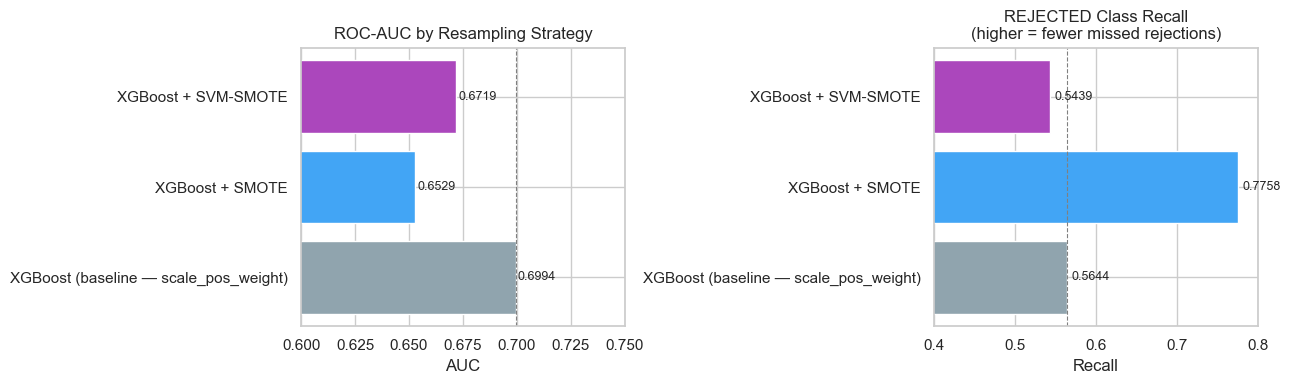


Key: ROC-AUC measures overall ranking; PR-AUC is often more informative under imbalance; REJECTED recall measures minority-class capture.
Resampling trades off AUC / PR-AUC vs minority-class recall — neither is universally 'better'.


In [29]:
# ── O5. Full Comparison — All Resampling Strategies ──────────────────────────

cr_xgb_res = classification_report(y_test, y_pred_xgb, output_dict=True)

results_resample = pd.DataFrame({
    "Strategy": [
        "XGBoost (baseline — scale_pos_weight)",
        "XGBoost + SMOTE",
        "XGBoost + SVM-SMOTE",
    ],
    "ROC-AUC":     [xgb_auc,    smote_auc, svms_auc],
    "PR-AUC":      [xgb_ap,     smote_ap,  svms_ap],
    "Weighted-F1": [xgb_f1w,    smote_f1,  svms_f1],
    "REJECTED-Precision": [
        float(cr_xgb_res["0"]["precision"]),
        float(classification_report(y_test, y_pred_smote, output_dict=True)["0"]["precision"]),
        float(classification_report(y_test, y_pred_svms,  output_dict=True)["0"]["precision"]),
    ],
    "REJECTED-Recall": [
        float(cr_xgb_res["0"]["recall"]),
        float(classification_report(y_test, y_pred_smote, output_dict=True)["0"]["recall"]),
        float(classification_report(y_test, y_pred_svms,  output_dict=True)["0"]["recall"]),
    ],
}).set_index("Strategy").round(4)

display(results_resample)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ["#90A4AE", "#42A5F5", "#AB47BC", "#26A69A"]

axes[0].barh(results_resample.index, results_resample["ROC-AUC"], color=colors)
axes[0].set_xlim(0.60, 0.75)
axes[0].axvline(xgb_auc, color="gray", linestyle="--", linewidth=0.8, label="Baseline AUC")
axes[0].set_title("ROC-AUC by Resampling Strategy")
axes[0].set_xlabel("AUC")
for i, v in enumerate(results_resample["ROC-AUC"]):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

axes[1].barh(results_resample.index, results_resample["REJECTED-Recall"], color=colors)
axes[1].axvline(float(cr_xgb_res["0"]["recall"]), color="gray", linestyle="--", linewidth=0.8, label="Baseline Recall")
axes[1].set_xlim(0.40, 0.80)
axes[1].set_title("REJECTED Class Recall\n(higher = fewer missed rejections)")
axes[1].set_xlabel("Recall")
for i, v in enumerate(results_resample["REJECTED-Recall"]):
    axes[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey: ROC-AUC measures overall ranking; PR-AUC is often more informative under imbalance; REJECTED recall measures minority-class capture.")
print("Resampling trades off AUC / PR-AUC vs minority-class recall — neither is universally 'better'.")

# Key Findings

* The final modelling dataset contained 1,48,040 disposed bail cases with clearly identifiable outcomes classified as **ALLOWED** or **REJECTED**.

* Bail allowance outcomes dominated the dataset (~68%), indicating a substantial class imbalance in disposed cases.

* Ensemble models outperformed linear methods, with XGBoost achieving the strongest predictive performance (ROC-AUC ≈ 0.70), suggesting that bail outcomes contain measurable institutional and procedural patterns.

* High Court identity emerged as one of the most influential predictors, indicating substantial variation in bail adjudication patterns across jurisdictions.

* Hearing count showed a strong relationship with case outcomes, with prolonged procedural progression generally associated with lower probabilities of bail allowance.

* Bail category (`Mapped_Bail`) materially affected predictions, confirming that different bail types exhibit distinct disposal tendencies.

* Filing year and registration lag contributed to prediction quality, indicating temporal and administrative effects in bail disposal behaviour.

* SHAP-based explainability analysis showed that similarly structured cases could receive different predicted outcomes depending on the High Court, pointing toward institutional heterogeneity.

* Target encoding and one-hot encoding produced nearly identical results, demonstrating robustness of the modelling pipeline.

* Synthetic oversampling methods such as SMOTE and SVM-SMOTE underperformed relative to class-weighted XGBoost, suggesting that preserving the original judicial data distribution produced more reliable predictions.

* The moderate predictive performance indicates that administrative metadata alone cannot fully explain bail outcomes; case-specific legal arguments, judicial reasoning, and factual circumstances remain important unobserved factors.

* Leakage-prone disposal variables were excluded and encoding/imputation were performed after train-test splitting to maintain methodological validity.
